# 4-class Lund DNN classifier

This notebook trains a **4-class classifier** for the Lund secondary splitting channel:

| Class | Meaning |
|---:|---|
| 0 | unmatched |
| 1 | $g\to q\bar q$-like |
| 2 | $q\to qg$-like |
| 3 | $g\to gg$-like / flavourless-flavourless |

It drops `channel2 == 4` (`rest`) by default and **does not use `dpsi12` as an input feature**.  
`dpsi12` is kept only for post-training physics plots, including the cleanish-gg angular distribution.

In [1]:

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import dump, load
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "TensorFlow is required for this notebook. Install it with: pip install tensorflow"
    ) from exc

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.2


## 1. Paths

Change `CSV_PATH` if your file is somewhere else. The fallback list includes the uploaded sandbox path and common local names.

In [2]:

CSV_PATH = Path("../csv/merged_ML_ch2-800to1000.csv")

fallback_paths = [
    Path("merged_ML.csv"),
    Path("merged_ML(1).csv"),
    Path("../csv/merged_ML.csv"),
    Path("../merged_ML.csv"),
    Path("/mnt/data/merged_ML(1).csv"),
    Path("/mnt/data/merged_ML.csv"),
]

if not CSV_PATH.exists():
    for path in fallback_paths:
        if path.exists():
            CSV_PATH = path
            break

if not CSV_PATH.exists():
    raise FileNotFoundError(
        "Could not find merged_ML.csv. Set CSV_PATH to the location of your CSV."
    )

MODEL_DIR = Path("models_four_class")
OUTPUT_DIR = Path("outputs_four_class")
MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print("Using CSV:", CSV_PATH.resolve())
print("Model directory:", MODEL_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())

Using CSV: /Users/alexmendonca/Desktop/pic2/csv/merged_ML_ch2-800to1000.csv
Model directory: /Users/alexmendonca/Desktop/pic2/python/models_four_class
Output directory: /Users/alexmendonca/Desktop/pic2/python/outputs_four_class


## 2. Load CSV and build features

The DNN inputs are based on the CMS-style subjet variables plus engineered symmetric/asymmetric combinations.  
The target is `channel2`. `dpsi12` is explicitly excluded from the DNN inputs.

In [ ]:

def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add stable transformed and combination features.

    Important: this function does not touch dpsi12 except keeping it available
    for post-training plots.
    """
    df = df.copy()

    # Stabilize long-tailed positive variables.
    for col in ["pt_dispersion3", "pt_dispersion4"]:
        if col in df.columns:
            df[col] = np.log1p(df[col].clip(lower=0))

    if "kt2" in df.columns:
        df["kt2"] = np.log1p(df["kt2"].clip(lower=0))

    if "deltaR34" in df.columns:
        dr = df["deltaR34"].clip(lower=1e-4)
        df["deltaR34"] = np.log1p(1.0 / dr)

    # z variables
    df["z_sum"] = df["z1"] + df["z2"]
    df["z_absdiff"] = np.abs(df["z1"] - df["z2"])
    df["z_min"] = np.minimum(df["z1"], df["z2"])
    df["z_max"] = np.maximum(df["z1"], df["z2"])
    df["z_minmax_ratio"] = df["z_min"] / (df["z_max"] + 1e-8)

    # Pairwise subjet observables. Use sum/absdiff/min/max/ratio to avoid relying
    # too much on arbitrary subjet-3/subjet-4 ordering.
    paired_bases = [
        ("N_charged3", "N_charged4", "N_charged"),
        ("N_all3", "N_all4", "N_all"),
        ("pt_weight3", "pt_weight4", "pt_weight"),
        ("pt_dispersion3", "pt_dispersion4", "pt_dispersion"),
    ]

    for c3, c4, name in paired_bases:
        if c3 not in df.columns or c4 not in df.columns:
            continue
        v3 = df[c3]
        v4 = df[c4]
        vmin = np.minimum(v3, v4)
        vmax = np.maximum(v3, v4)
        df[f"{name}_sum"] = v3 + v4
        df[f"{name}_absdiff"] = np.abs(v3 - v4)
        df[f"{name}_min"] = vmin
        df[f"{name}_max"] = vmax
        df[f"{name}_minmax_ratio"] = vmin / (vmax + 1e-8)

    return df


df_raw = pd.read_csv(CSV_PATH)
print("Raw shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())

#df = add_engineered_features(df_raw)
df = df_raw.copy()

ORIGINAL_TARGET = "channel2"
if ORIGINAL_TARGET not in df.columns:
    raise ValueError(f"Missing target column {ORIGINAL_TARGET!r}")

df = df.dropna(subset=[ORIGINAL_TARGET]).copy()
df[ORIGINAL_TARGET] = df[ORIGINAL_TARGET].astype(int)

print("Original channel2 counts:")
display(df[ORIGINAL_TARGET].value_counts().sort_index().rename("count").to_frame())

Raw shape: (29874986, 18)
Columns: ['Event', 'Jet', 'Jet_pt', 'z1', 'z2', 'deltaR34', 'kt2', 'N_charged3', 'N_charged4', 'N_all3', 'N_all4', 'pt_weight3', 'pt_weight4', 'pt_dispersion3', 'pt_dispersion4', 'tau_time', 'channel2', 'dpsi12']
Original channel2 counts:


,count
channel2,
0,22689428
1,896936
2,1736862
3,4298461
4,253299


## 3. Select classes and define training inputs

Default behavior:

- Keep `channel2 = 0, 1, 2, 3`
- Drop `channel2 = 4` because it is small and ambiguous
- Drop identifiers and non-input variables: `Event`, `Jet`, `tau_time`, `dpsi12`, `channel2`

In [4]:

# Keep four classes: unmatched, qqbar, qg, gg.
KEEP_CLASSES = [0, 1, 2, 3]
df = df[df[ORIGINAL_TARGET].isin(KEEP_CLASSES)].copy()

CLASS_NAMES = {
    0: "unmatched",
    1: "qqbar",
    2: "qg",
    3: "gg-like",
}
expected_classes = np.array(KEEP_CLASSES, dtype=np.int64)

print("Counts after keeping classes 0,1,2,3:")
display(df[ORIGINAL_TARGET].value_counts().sort_index().rename("count").to_frame())
print("Fractions:")
display((100 * df[ORIGINAL_TARGET].value_counts(normalize=True).sort_index()).rename("percent").to_frame())

# Never use dpsi12 as an input feature.
ADDITIONAL_COLUMNS_TO_DROP = ["Event", "Jet", "dpsi12","tau_time"]
columns_to_drop = sorted(
    set([ORIGINAL_TARGET] + ADDITIONAL_COLUMNS_TO_DROP),
    key=lambda col: list(df.columns).index(col) if col in df.columns else 10**9,
)

feature_columns = [col for col in df.columns if col not in columns_to_drop]

# Keep only numeric features.
X = df[feature_columns].copy()
non_numeric_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_columns:
    raise ValueError(f"Non-numeric feature columns found: {non_numeric_columns}")

# Replace inf with nan so the imputer can handle them.
X = X.replace([np.inf, -np.inf], np.nan)
y = df[ORIGINAL_TARGET].to_numpy(dtype=np.int64)

print("Dropped columns:", columns_to_drop)
print("Number of features:", len(feature_columns))
print("Feature columns:")
for c in feature_columns:
    print("  -", c)

assert "dpsi12" not in feature_columns
assert ORIGINAL_TARGET not in feature_columns

Counts after keeping classes 0,1,2,3:


,count
channel2,
0,22689428
1,896936
2,1736862
3,4298461


Fractions:


,percent
channel2,
0,76.597352
1,3.027971
2,5.863481
3,14.511196


Dropped columns: ['Event', 'Jet', 'tau_time', 'channel2', 'dpsi12']
Number of features: 13
Feature columns:
  - Jet_pt
  - z1
  - z2
  - deltaR34
  - kt2
  - N_charged3
  - N_charged4
  - N_all3
  - N_all4
  - pt_weight3
  - pt_weight4
  - pt_dispersion3
  - pt_dispersion4


## 4. Event-level train/validation/test split and preprocessing

Splitting by event is safer than row-wise random splitting because it avoids putting jets from the same event in both train and test.

In [5]:

USE_EVENT_GROUP_SPLIT = "Event" in df.columns

if USE_EVENT_GROUP_SPLIT:
    groups = df["Event"].to_numpy()

    splitter_test = GroupShuffleSplit(n_splits=1, test_size=0.33, random_state=RANDOM_STATE)
    trainval_idx, test_idx = next(splitter_test.split(X, y, groups=groups))

    X_trainval = X.iloc[trainval_idx]
    X_test = X.iloc[test_idx]
    y_trainval = y[trainval_idx]
    y_test = y[test_idx]
    groups_trainval = groups[trainval_idx]

    splitter_val = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=RANDOM_STATE + 1)
    train_rel_idx, val_rel_idx = next(splitter_val.split(X_trainval, y_trainval, groups=groups_trainval))

    X_train = X_trainval.iloc[train_rel_idx]
    X_val = X_trainval.iloc[val_rel_idx]
    y_train = y_trainval[train_rel_idx]
    y_val = y_trainval[val_rel_idx]
else:
    print("No Event column found. Falling back to stratified row-wise split.")
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y,
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.15, random_state=RANDOM_STATE, stratify=y_trainval,
    )

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

print("\nClass fractions:")
for name, yy in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    vc = pd.Series(yy).value_counts(normalize=True).sort_index()
    print(name)
    for c in expected_classes:
        print(f"  {c} {CLASS_NAMES[int(c)]:>10s}: {vc.get(c, 0.0):.4%}")

preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

X_train_pp = preprocessor.fit_transform(X_train).astype("float32")
X_val_pp = preprocessor.transform(X_val).astype("float32")
X_test_pp = preprocessor.transform(X_test).astype("float32")

dump(preprocessor, MODEL_DIR / "four_class_preprocessor.joblib")
with open(MODEL_DIR / "four_class_feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=2)

print("Saved preprocessor and feature list.")

Train: (9923919, 13) Validation: (9921507, 13) Test: (9776261, 13)

Class fractions:
Train
  0  unmatched: 76.5824%
  1      qqbar: 3.0259%
  2         qg: 5.8577%
  3    gg-like: 14.5340%
Validation
  0  unmatched: 76.6046%
  1      qqbar: 3.0336%
  2         qg: 5.8633%
  3    gg-like: 14.4984%
Test
  0  unmatched: 76.6052%
  1      qqbar: 3.0243%
  2         qg: 5.8695%
  3    gg-like: 14.5010%
Saved preprocessor and feature list.


## 5. Class weights

The sample is strongly imbalanced, especially because `unmatched` dominates. Class weights help the network not ignore the smaller classes.

In [6]:

alpha_power = 0.75  # 1.0 = full balanced weights, 0.5 = softer, 0.0 = no weighting

raw_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=expected_classes,
    y=y_train,
)
class_weight_map = {
    int(c): float(w ** alpha_power)
    for c, w in zip(expected_classes, raw_class_weights)
}

print("Raw balanced weights:")
print({int(c): float(w) for c, w in zip(expected_classes, raw_class_weights)})
print("\nWeights used:")
print(class_weight_map)

Raw balanced weights:
{0: 0.3264459495963866, 1: 8.261890926165199, 2: 4.267904357564196, 3: 1.7201014667087278}

Weights used:
{0: 0.4318753963846621, 1: 4.8731479046317325, 2: 2.969347385052261, 3: 1.5019848414065713}


## 6. Build and train the 4-class DNN

In [7]:

def build_four_class_dnn(input_dim: int, n_classes: int = 4) -> keras.Model:
    model = keras.Sequential(
        [
            layers.Input(shape=(input_dim,), name="features"),

            layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-5), name="dense_1"),
            layers.BatchNormalization(name="bn_1"),
            layers.Dropout(0.20, name="dropout_1"),

            layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-5), name="dense_2"),
            layers.BatchNormalization(name="bn_2"),
            layers.Dropout(0.20, name="dropout_2"),

            layers.Dense(64, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-5), name="dense_3"),
            layers.BatchNormalization(name="bn_3"),
            layers.Dropout(0.10, name="dropout_3"),

            layers.Dense(n_classes, activation="softmax", name="class_probabilities"),
        ],
        name="lund_four_class_dnn",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = build_four_class_dnn(input_dim=X_train_pp.shape[1], n_classes=len(expected_classes))
model.summary()

Model: "lund_four_class_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,788 (182.77 KB)

 Trainable params: 45,892 (179.27 KB)

 Non-trainable params: 896 (3.50 KB)

In [8]:
class ValMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val, batch_size=8192):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.batch_size = batch_size

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        y_score = self.model.predict(
            self.X_val,
            batch_size=self.batch_size,
            verbose=0
        )
        y_pred = np.argmax(y_score, axis=1)

        logs["val_macro_f1"] = f1_score(
            self.y_val,
            y_pred,
            average="macro",
            zero_division=0
        )

        logs["val_balanced_accuracy"] = balanced_accuracy_score(
            self.y_val,
            y_pred
        )

        print(
            f" — val_macro_f1: {logs['val_macro_f1']:.4f}"
            f" — val_balanced_accuracy: {logs['val_balanced_accuracy']:.4f}"
        )

In [9]:
EPOCHS = 100
BATCH_SIZE = 1024
MONITOR_METRIC = "val_macro_f1"

val_metrics = ValMetricsCallback(X_val_pp, y_val)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(MODEL_DIR / "four_class_dnn_best.keras"),
    monitor=MONITOR_METRIC,
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor=MONITOR_METRIC,
    mode="max",
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor=MONITOR_METRIC,
    mode="max",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1,
)

callbacks = [
    val_metrics,
    checkpoint,
    early_stop,
    reduce_lr,
]

history = model.fit(
    X_train_pp,
    y_train,
    validation_data=(X_val_pp, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_map,
    callbacks=callbacks,
    verbose=1,
)

model.save(MODEL_DIR / "four_class_dnn_final.keras")

print("Best validation loss:", min(history.history["val_loss"]))
print("Best validation macro F1:", max(history.history["val_macro_f1"]))
print("Best validation balanced accuracy:", max(history.history["val_balanced_accuracy"]))

Epoch 1/100
9690/9692 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7133 - loss: 0.9857 — val_macro_f1: 0.4323 — val_balanced_accuracy: 0.4475

Epoch 1: val_macro_f1 improved from None to 0.43233, saving model to models_four_class/four_class_dnn_best.keras

Epoch 1: finished saving model to models_four_class/four_class_dnn_best.keras
9692/9692 ━━━━━━━━━━━━━━━━━━━━ 115s 12ms/step - accuracy: 0.7293 - loss: 0.9654 - val_accuracy: 0.7439 - val_loss: 0.7992 - val_macro_f1: 0.4323 - val_balanced_accuracy: 0.4475 - learning_rate: 0.0010
Epoch 2/100
9689/9692 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7354 - loss: 0.9555 — val_macro_f1: 0.4323 — val_balanced_accuracy: 0.4490

Epoch 2: val_macro_f1 improved from 0.43233 to 0.43234, saving model to models_four_class/four_class_dnn_best.keras

Epoch 2: finished saving model to models_four_class/four_class_dnn_best.keras
9692/9692 ━━━━━━━━━━━━━━━━━━━━ 106s 11ms/step - accuracy: 0.7356 - loss: 0.9547 - val_accuracy: 0.7467 - val_loss: 0.7911 

## 7. Training curves

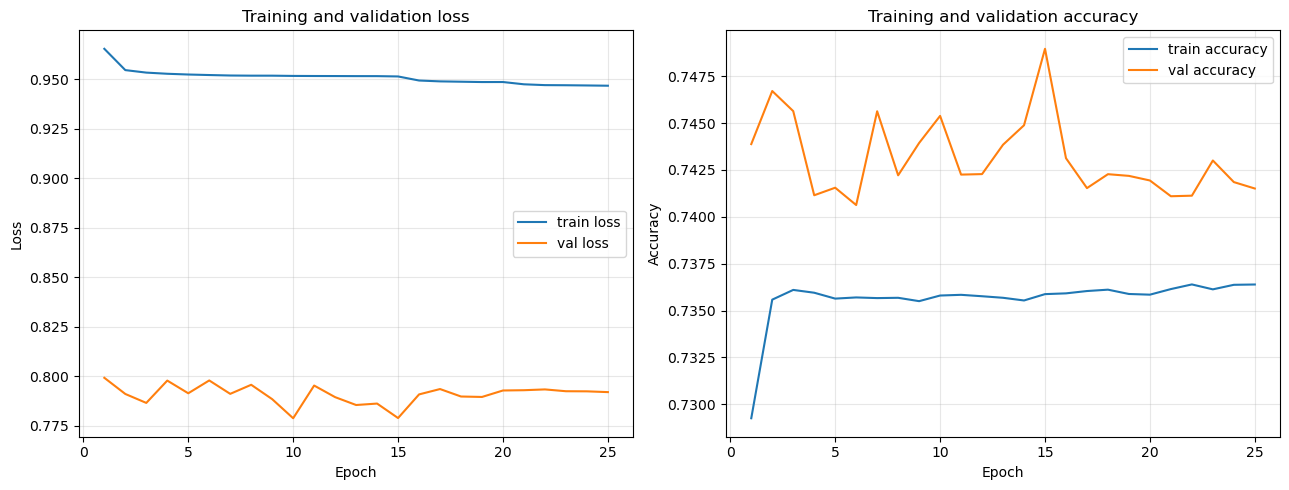

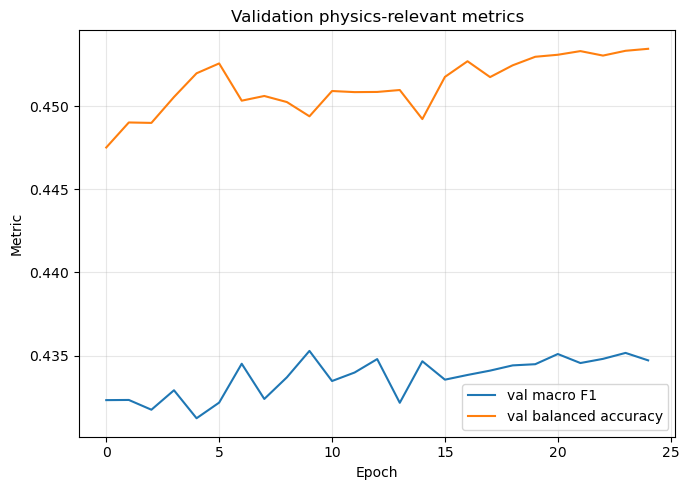

In [10]:

def plot_training_curves(history):
    hist = history.history
    epochs = np.arange(1, len(hist["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(epochs, hist["loss"], label="train loss")
    axes[0].plot(epochs, hist["val_loss"], label="val loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training and validation loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, hist["accuracy"], label="train accuracy")
    axes[1].plot(epochs, hist["val_accuracy"], label="val accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Training and validation accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=160)
    plt.show()

plot_training_curves(history)

plt.figure(figsize=(7, 5))
plt.plot(history.history["val_macro_f1"], label="val macro F1")
plt.plot(history.history["val_balanced_accuracy"], label="val balanced accuracy")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Validation physics-relevant metrics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Test-set evaluation

This evaluates the 4-class classifier with:

- classification report
- confusion matrix
- one-vs-rest ROC-AUC and PR-AUC for each class
- score distributions by true class

Validation accuracy: 0.7453838413861926
Validation balanced accuracy: 0.449382827881444
Test accuracy: 0.7453947884574685
Test balanced accuracy: 0.44972544278981197

Test classification report:
              precision    recall  f1-score   support

   unmatched     0.8869    0.8580    0.8722   7489125
       qqbar     0.1971    0.2978    0.2372    295663
          qg     0.2479    0.1639    0.1973    573821
     gg-like     0.3984    0.4792    0.4351   1417652

    accuracy                         0.7454   9776261
   macro avg     0.4326    0.4497    0.4355   9776261
weighted avg     0.7577    0.7454    0.7500   9776261



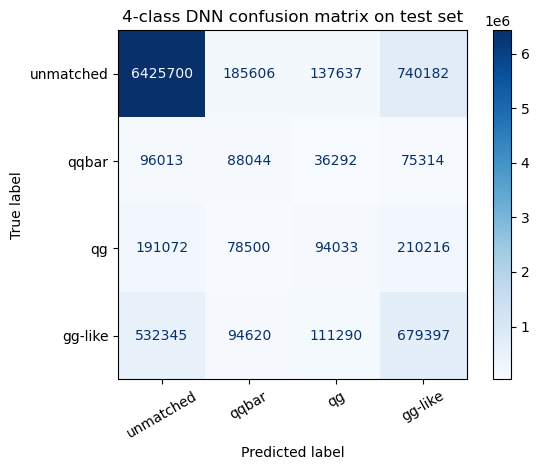

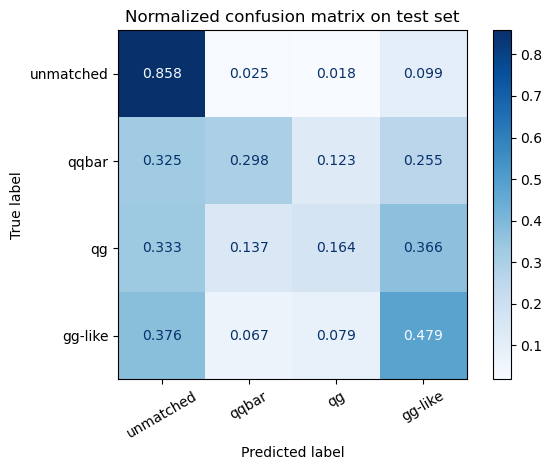

In [11]:

def predict_scores(model, X_pp):
    return model.predict(X_pp, batch_size=8192, verbose=0)

score_val = predict_scores(model, X_val_pp)
score_test = predict_scores(model, X_test_pp)

pred_val = score_val.argmax(axis=1)
pred_test = score_test.argmax(axis=1)

print("Validation accuracy:", accuracy_score(y_val, pred_val))
print("Validation balanced accuracy:", balanced_accuracy_score(y_val, pred_val))
print("Test accuracy:", accuracy_score(y_test, pred_test))
print("Test balanced accuracy:", balanced_accuracy_score(y_test, pred_test))

print("\nTest classification report:")
print(classification_report(
    y_test,
    pred_test,
    labels=expected_classes,
    target_names=[CLASS_NAMES[int(c)] for c in expected_classes],
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_test, pred_test, labels=expected_classes)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[CLASS_NAMES[int(c)] for c in expected_classes],
)
disp.plot(values_format="d", cmap="Blues", xticks_rotation=30)
plt.title("4-class DNN confusion matrix on test set")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_test.png", dpi=160)
plt.show()

cm_norm = confusion_matrix(y_test, pred_test, labels=expected_classes, normalize="true")
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=[CLASS_NAMES[int(c)] for c in expected_classes],
)
disp.plot(values_format=".3f", cmap="Blues", xticks_rotation=30)
plt.title("Normalized confusion matrix on test set")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_test_normalized.png", dpi=160)
plt.show()

In [12]:

# One-vs-rest ROC-AUC and PR-AUC per class
rows = []
for c in expected_classes:
    y_true_c = (y_test == c).astype(int)
    y_score_c = score_test[:, int(c)]

    roc = roc_auc_score(y_true_c, y_score_c)
    pr = average_precision_score(y_true_c, y_score_c)
    baseline = y_true_c.mean()

    rows.append({
        "class": int(c),
        "name": CLASS_NAMES[int(c)],
        "fraction": baseline,
        "roc_auc": roc,
        "pr_auc": pr,
    })

metric_df = pd.DataFrame(rows)
display(metric_df)
metric_df.to_csv(OUTPUT_DIR / "one_vs_rest_metrics.csv", index=False)

,class,name,fraction,roc_auc,pr_auc
0,0,unmatched,0.766052,0.840467,0.940278
1,1,qqbar,0.030243,0.814226,0.186837
2,2,qg,0.058695,0.792340,0.202034
3,3,gg-like,0.145010,0.793828,0.401159


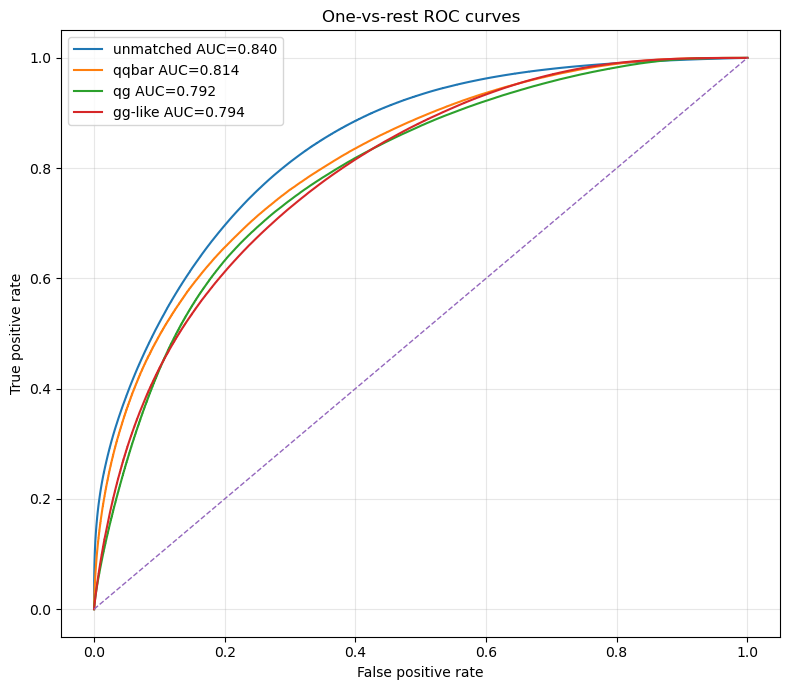

In [13]:

# ROC curves
plt.figure(figsize=(8, 7))
for c in expected_classes:
    y_true_c = (y_test == c).astype(int)
    y_score_c = score_test[:, int(c)]
    fpr, tpr, _ = roc_curve(y_true_c, y_score_c)
    roc = roc_auc_score(y_true_c, y_score_c)
    plt.plot(fpr, tpr, label=f"{CLASS_NAMES[int(c)]} AUC={roc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("One-vs-rest ROC curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curves_one_vs_rest.png", dpi=160)
plt.show()

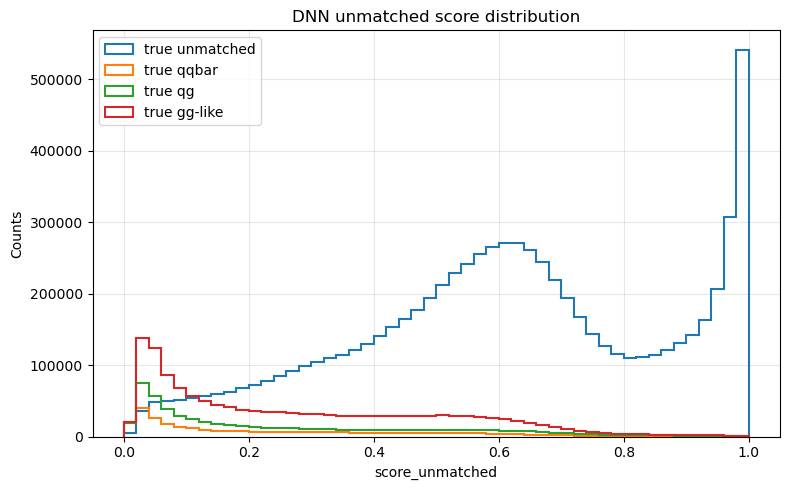

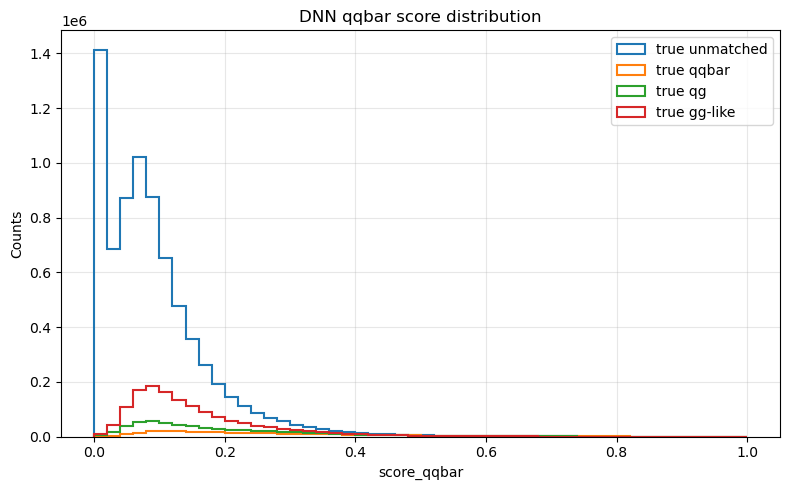

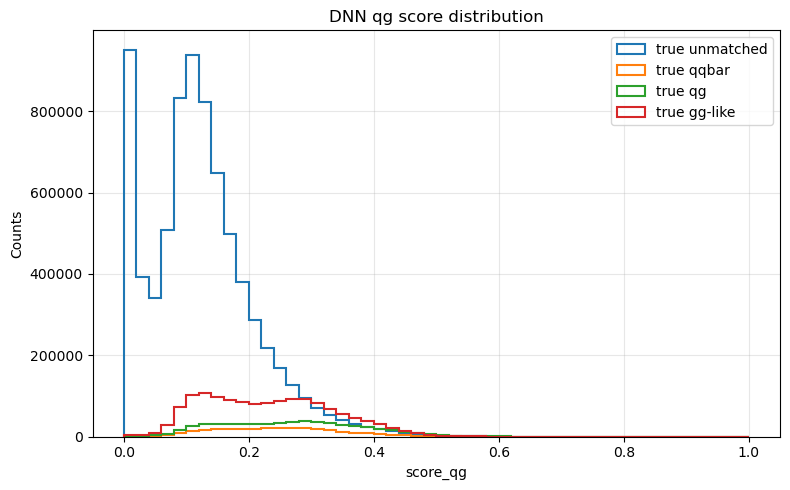

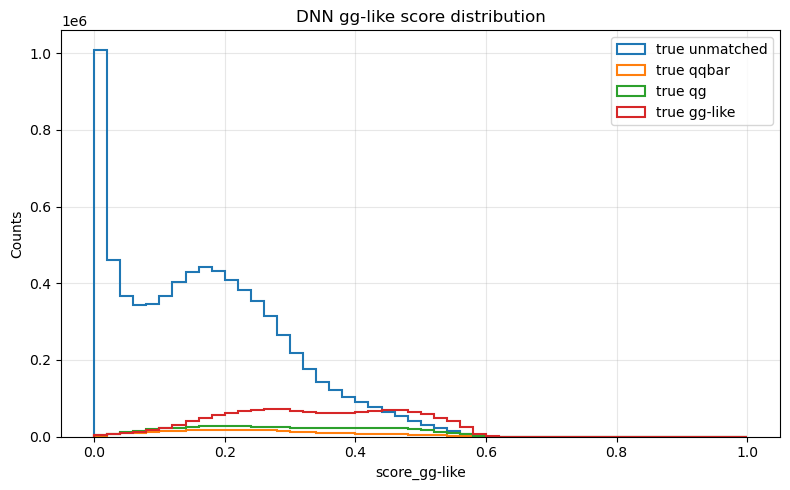

In [14]:

# Score distributions by true class
for c in expected_classes:
    plt.figure(figsize=(8, 5))
    bins = np.linspace(0, 1, 51)
    for true_c in expected_classes:
        mask = y_test == true_c
        plt.hist(
            score_test[mask, int(c)],
            bins=bins,
            histtype="step",
            density=False,
            linewidth=1.5,
            label=f"true {CLASS_NAMES[int(true_c)]}",
            range=[0.5, 1.0]
        )
        max_score = score_test[mask, int(c)].max()
    plt.xlabel(f"score_{CLASS_NAMES[int(c)]}")
    plt.ylabel("Counts")
    plt.title(f"DNN {CLASS_NAMES[int(c)]} score distribution")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"score_distribution_class_{int(c)}.png", dpi=160)
    plt.show()

## Plot dpsi12 of test subjects

- score_qqbar > 0.6, score_qg > 0.6, score_gg > 0.6, score_unmacted > 0.6

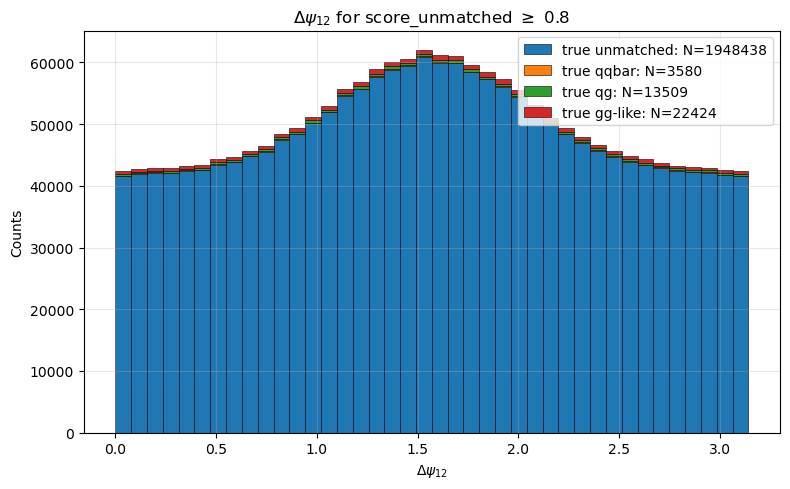

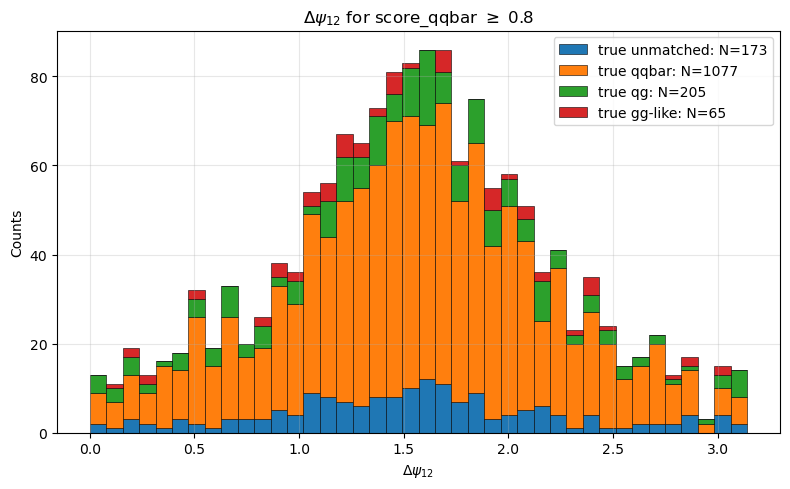

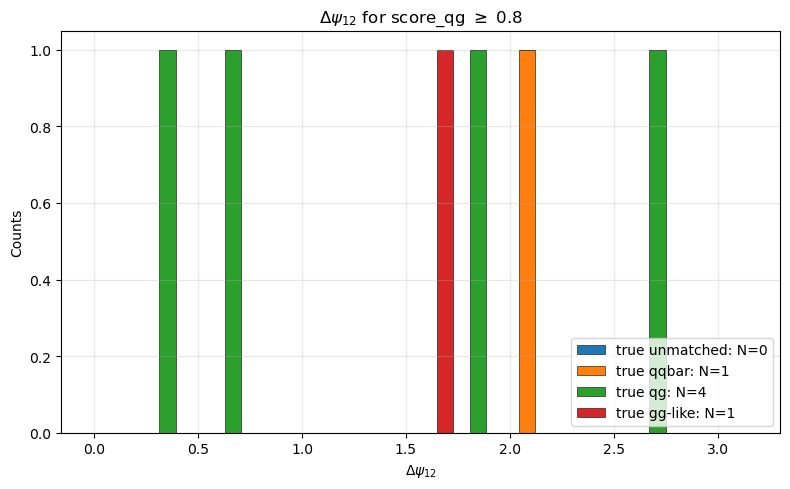

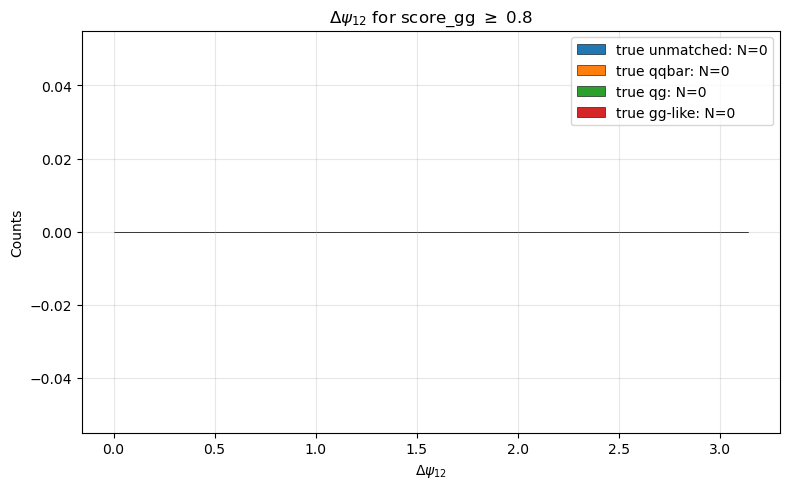

In [17]:
# Plot dpsi12 of test subjects with score >= 0.6
# One stacked histogram per score cut.
# Stack components are the true labels.

SCORE_THRESHOLD = 0.8
BINS = 40

score_class_names = {
    0: "unmatched",
    1: "qqbar",
    2: "qg",
    3: "gg",
}

test_df = df.loc[X_test.index].copy()
dpsi_test = test_df["dpsi12"].to_numpy(dtype=float)

finite_dpsi = dpsi_test[np.isfinite(dpsi_test)]
if np.nanmax(np.abs(finite_dpsi)) > 2 * np.pi + 0.5:
    print("dpsi12 looks like degrees; converting to radians.")
    dpsi_test = np.deg2rad(dpsi_test)

finite_dpsi = dpsi_test[np.isfinite(dpsi_test)]
if finite_dpsi.min() >= -0.05 and finite_dpsi.max() <= np.pi + 0.05:
    dpsi_range = (0, np.pi)
else:
    dpsi_range = (finite_dpsi.min(), finite_dpsi.max())

for score_class in expected_classes:
    score_class = int(score_class)

    score_mask = score_test[:, score_class] >= SCORE_THRESHOLD

    hist_data = []
    hist_labels = []

    for true_class in expected_classes:
        true_class = int(true_class)

        mask = (
            score_mask
            & (y_test == true_class)
            & np.isfinite(dpsi_test)
        )

        hist_data.append(dpsi_test[mask])
        hist_labels.append(f"true {CLASS_NAMES[true_class]}: N={mask.sum()}")

    plt.figure(figsize=(8, 5))

    plt.hist(
        hist_data,
        bins=BINS,
        range=dpsi_range,
        stacked=True,
        label=hist_labels,
        edgecolor="black",
        linewidth=0.4,
    )

    plt.xlabel(r"$\Delta\psi_{12}$")
    plt.ylabel("Counts")
    plt.title(
        rf"$\Delta\psi_{{12}}$ for score_{score_class_names[score_class]} $\geq$ {SCORE_THRESHOLD}"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    outname = OUTPUT_DIR / f"dpsi12_score_{score_class_names[score_class]}_ge_{SCORE_THRESHOLD:.1f}_stacked.png"
    plt.savefig(outname, dpi=160)
    plt.show()

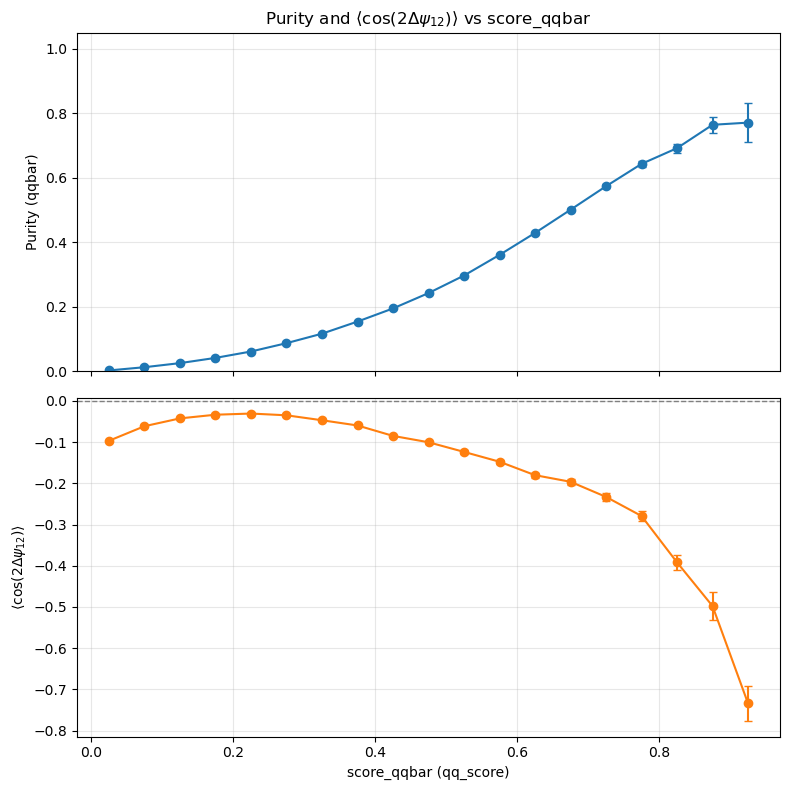

,score_bin_center,n_events,purity,purity_err,mean_cos2dpsi,mean_cos2dpsi_err
0,0.025,2648767,0.002947,0.000033,-0.096684,0.000436
1,0.075,2960350,0.012923,0.000066,-0.061320,0.000413
2,0.125,1839720,0.025611,0.000116,-0.042322,0.000526
3,0.175,953647,0.041831,0.000205,-0.033453,0.000733
4,0.225,519756,0.061608,0.000334,-0.030596,0.000994
5,0.275,320903,0.087435,0.000499,-0.034856,0.001267
6,0.325,201164,0.116865,0.000716,-0.046878,0.001605
7,0.375,123325,0.154340,0.001029,-0.059537,0.002041
8,0.425,75374,0.195081,0.001443,-0.084848,0.002615
9,0.475,47531,0.242642,0.001966,-0.100269,0.003274


In [16]:
# --- Purity and <cos(2*dpsi12)> vs qq_score (class-1 "g->qqbar" score) ---

QQ_CLASS = 1
N_SCORE_BINS = 20
MIN_COUNTS_PER_BIN = 20  # bins with fewer test events than this are left blank

qq_score = score_test[:, QQ_CLASS]

# dpsi12 for the test set, same unit handling as the dpsi12 plotting cell above
test_df = df.loc[X_test.index].copy()
dpsi_test = test_df["dpsi12"].to_numpy(dtype=float)

finite_dpsi = dpsi_test[np.isfinite(dpsi_test)]
if np.nanmax(np.abs(finite_dpsi)) > 2 * np.pi + 0.5:
    dpsi_test = np.deg2rad(dpsi_test)

cos2dpsi_test = np.cos(2.0 * dpsi_test)

score_bin_edges = np.linspace(0.0, 1.0, N_SCORE_BINS + 1)
bin_centers = 0.5 * (score_bin_edges[:-1] + score_bin_edges[1:])
bin_idx = np.digitize(qq_score, score_bin_edges[1:-1], right=False)  # 0..N_SCORE_BINS-1

purity = np.full(N_SCORE_BINS, np.nan)
purity_err = np.full(N_SCORE_BINS, np.nan)
mean_cos2dpsi = np.full(N_SCORE_BINS, np.nan)
mean_cos2dpsi_err = np.full(N_SCORE_BINS, np.nan)
n_in_bin = np.zeros(N_SCORE_BINS, dtype=int)

for b in range(N_SCORE_BINS):
    sel = bin_idx == b
    n = sel.sum()
    n_in_bin[b] = n
    if n < MIN_COUNTS_PER_BIN:
        continue

    is_true_qq = (y_test[sel] == QQ_CLASS)
    p = is_true_qq.mean()
    purity[b] = p
    purity_err[b] = np.sqrt(p * (1 - p) / n)  # binomial error

    finite = np.isfinite(cos2dpsi_test[sel])
    vals = cos2dpsi_test[sel][finite]
    if len(vals) > 1:
        mean_cos2dpsi[b] = vals.mean()
        mean_cos2dpsi_err[b] = vals.std(ddof=1) / np.sqrt(len(vals))
    elif len(vals) == 1:
        mean_cos2dpsi[b] = vals.mean()

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].errorbar(bin_centers, purity, yerr=purity_err, fmt="o-", capsize=3)
axes[0].set_ylabel(f"Purity ({CLASS_NAMES[QQ_CLASS]})")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)
axes[0].set_title(rf"Purity and $\langle\cos(2\Delta\psi_{{12}})\rangle$ vs score_{CLASS_NAMES[QQ_CLASS]}")

axes[1].errorbar(bin_centers, mean_cos2dpsi, yerr=mean_cos2dpsi_err, fmt="o-", capsize=3, color="tab:orange")
axes[1].axhline(0, linestyle="--", linewidth=1, color="gray")
axes[1].set_ylabel(r"$\langle\cos(2\Delta\psi_{12})\rangle$")
axes[1].set_xlabel(f"score_{CLASS_NAMES[QQ_CLASS]} (qq_score)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "purity_and_cos2dpsi_vs_qq_score.png", dpi=160)
plt.show()

summary_df = pd.DataFrame({
    "score_bin_center": bin_centers,
    "n_events": n_in_bin,
    "purity": purity,
    "purity_err": purity_err,
    "mean_cos2dpsi": mean_cos2dpsi,
    "mean_cos2dpsi_err": mean_cos2dpsi_err,
})
display(summary_df)